# House Price Prediction using Machine Learning

## **1. Project Overview**

House price estimation plays an important role in the real estate industry, helping buyers, sellers, and property developers make informed decisions. In this project, machine learning techniques are used to predict the selling price of a house based on various property characteristics such as area, number of bedrooms, bathrooms, stories, parking availability, furnishing status, and other features.

The workflow includes:

- Understanding and exploring the dataset
- Cleaning and preprocessing the data
- Converting categorical features into numerical form
- Building prediction models using Linear Regression and Random Forest Regressor
- Evaluating model performance using standard regression metrics
- Visualizing important relationships within the dataset
- Drawing meaningful insights from the results

The objective is not only to build an accurate prediction model but also to understand which property features contribute the most to house prices.

**2. Importing the Required Libraries**
---

In [1]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set a clean plotting style
sns.set_style("whitegrid")

print("All required libraries have been imported successfully.")

All required libraries have been imported successfully.


# **3. Loading the Dataset**

The first step in any machine learning project is to load the dataset into a suitable data structure. Here, the housing dataset is read using the Pandas library and stored in a DataFrame.

After loading the data, the first few records are displayed to verify that the dataset has been imported correctly.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
housing_data = pd.read_csv("/content/drive/MyDrive/XylofyAI/Housing.csv")

print("Dataset loaded successfully.")

print(f"\nNumber of rows or records   : {housing_data.shape[0]}")
print(f"Number of columns or features : {housing_data.shape[1]}")

Dataset loaded successfully.

Number of rows or records   : 545
Number of columns or features : 13


**Displaying First 10 Records**
---

In [7]:
# Display the first ten records of the dataset

housing_data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


# Exploring the Dataset

Before building any machine learning model, it is important to understand the structure of the dataset.

In this section, I examined:

- Number of observations
- Number of features
- Data types of each column
- Target variable
- Basic information about the dataset

This helps identify potential preprocessing steps before model training.

**Dataset Information**
---

In [11]:
print("Shape of the Dataset")
print("-----------")
print(housing_data.shape)

print("\nColumn Names")
print("--------------------" )
print(housing_data.columns.tolist())

print("\nDataset Information")
print("-----------------------------" )

housing_data.info()

Shape of the Dataset
-----------
(545, 13)

Column Names
--------------------
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Dataset Information
-----------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int

### Interpretation

The dataset contains **545 observations** and **13 features**, including both numerical and categorical variables.

The target variable is **price**, while the remaining attributes describe different characteristics of a house such as area, number of bedrooms, parking availability, and furnishing status.

The categorical variables will be converted into numerical form during preprocessing.

**Statistical Summary of the dataset**
---

In [13]:
housing_data.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


### Interpretation

The statistical summary shows considerable variation in house prices and property sizes.

The large difference between the minimum and maximum values suggests that the dataset contains houses belonging to different price segments.

The average house area is around the middle of the observed range, indicating a balanced distribution without obvious data entry issues.

# **4. Data Cleaning**

After examining the dataset, the necessary cleaning steps are performed.

The housing dataset used in this project is already well-structured and contains no missing values. However, duplicate records, if present, are removed to ensure that every observation represents a unique property.

Cleaning the data before model training improves the reliability of the predictions.

**Checking Missing Values**
---

In [ ]:

missing_value_summary = housing_data.isnull().sum()

print("Missing Values in Each Column")
print("-" * 40)

print(missing_value_summary)

Missing Values in Each Column
----------------------------------------
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


**Checking Duplicate Records**
---

In [ ]:
duplicate_count = housing_data.duplicated().sum()

print(f"Number of duplicate records : {duplicate_count}")

Number of duplicate records : 0


**Remove Duplicates**
---

In [16]:
housing_data = housing_data.drop_duplicates()

print("Updated Dataset Shape")
print("-" * 40)
print(housing_data.shape)

Updated Dataset Shape
----------------------------------------
(545, 13)


# **5. Exploratory Data Analysis**

Real-world datasets often contain missing values, duplicate records, or inconsistent data. Such issues can negatively affect the performance of machine learning models.

In this section, the dataset is checked for:

- Missing values
- Duplicate records
- Overall data quality

These checks help ensure that the dataset is reliable before moving to the preprocessing stage.

# Distribution of Numerical Features - Univariate Analysis

Before building predictive models, it is useful to examine the distribution of important numerical variables.

Histograms help identify skewness, spread, and possible outliers in the data.

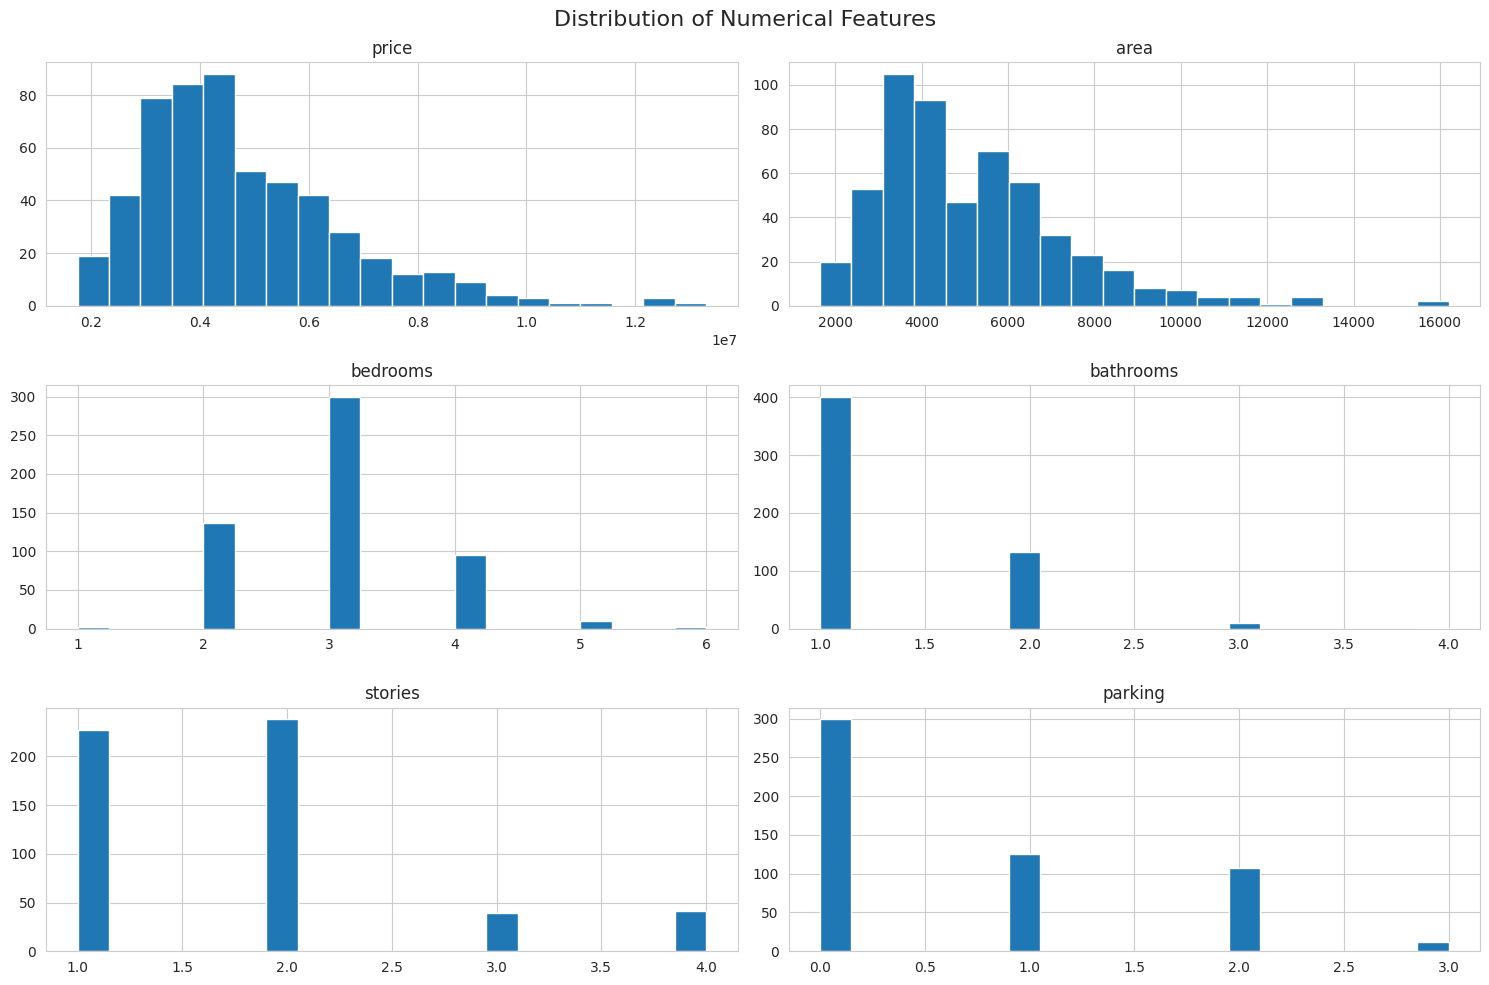

In [38]:
numerical_columns = housing_data.select_dtypes(include=["int64", "float64"]).columns

housing_data[numerical_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

**Bivariate Analysis**
---

# Relationship Between House Area and Price

House area is generally expected to have a positive influence on property prices.

The following scatter plot helps visualize this relationship.

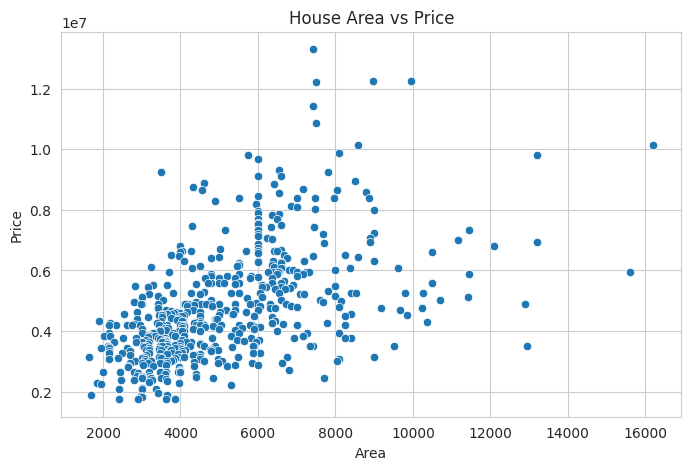

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=housing_data,
    x="area",
    y="price"
)

plt.title("House Area vs Price")

plt.xlabel("Area")

plt.ylabel("Price")

plt.show()

### Observation

The scatter plot shows a clear positive relationship between area and selling price.

Larger houses generally command higher prices, although some variation exists due to other influencing factors such as location and amenities.

**Boxplots for Categorical/Discrete Features vs. Price**
---

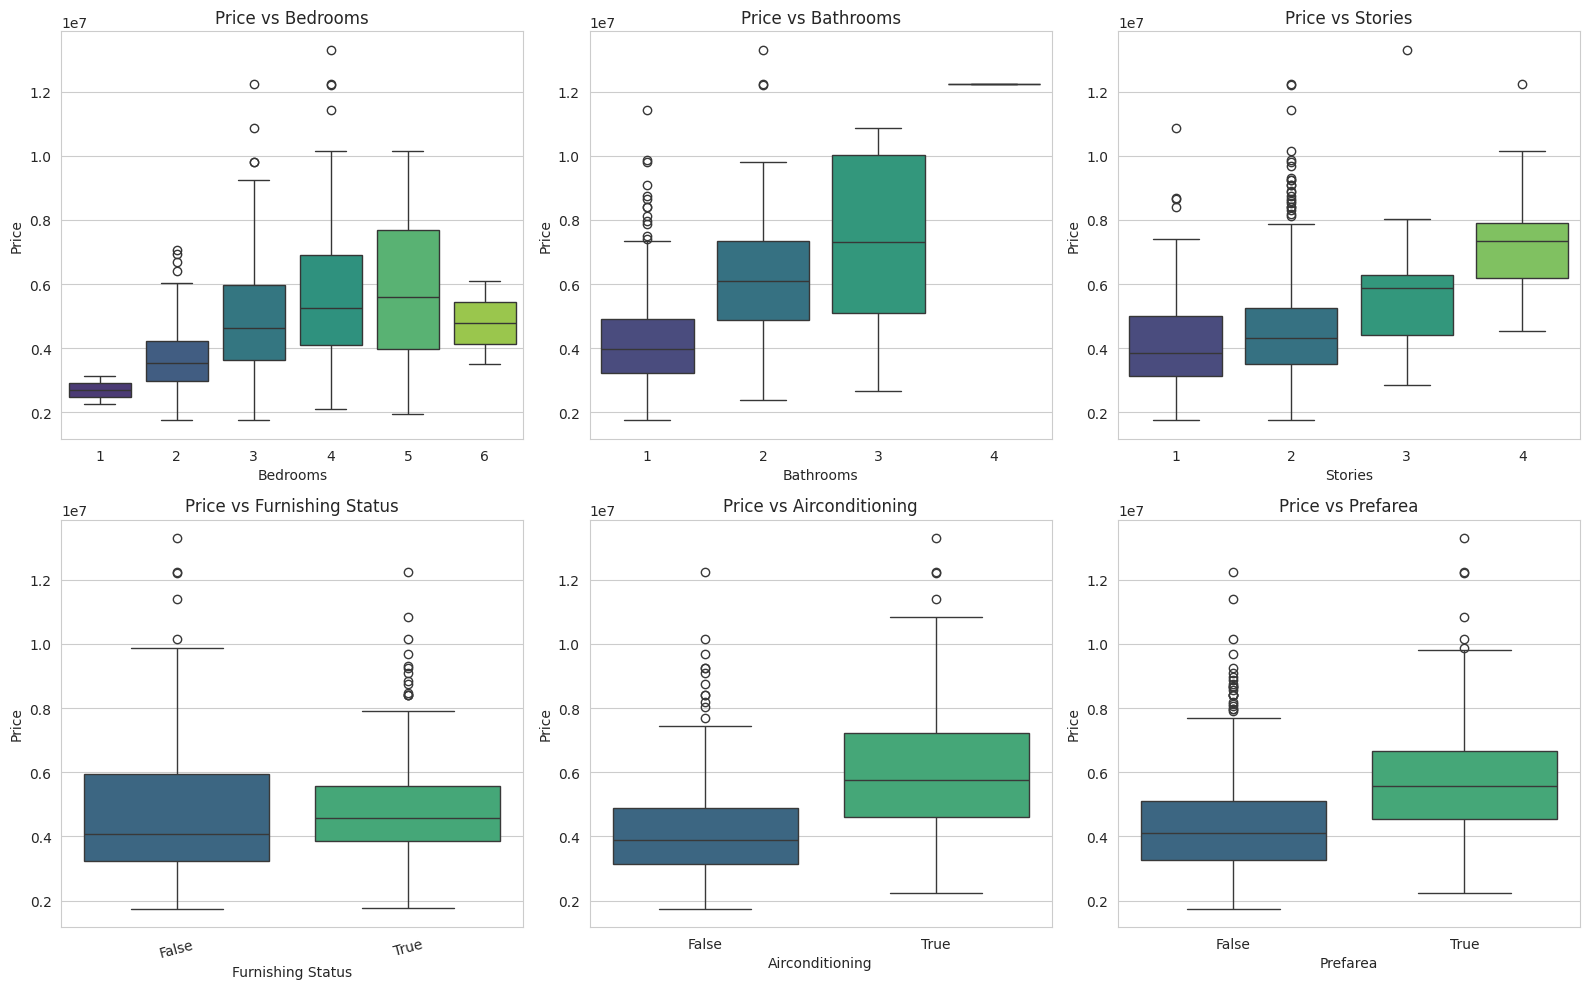

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Consolidated Boxplots for Categorical/Discrete Features vs. Price
# Updated feature names to reflect one-hot encoding
features_to_plot = ['bedrooms', 'bathrooms', 'stories', 'furnishingstatus_semi-furnished', 'airconditioning_yes', 'prefarea_yes']

plt.figure(figsize=(16, 10))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=housing_data, x=feature, y='price', palette='viridis')

    # Custom title and x-label for better readability of encoded features
    if feature.endswith('_yes'):
        title_label = feature.replace('_yes', '').replace('_', ' ').title()
        x_label = feature.replace('_yes', '').replace('_', ' ').title()
    elif 'furnishingstatus' in feature:
        title_label = 'Furnishing Status'
        x_label = 'Furnishing Status'
    else:
        title_label = feature.capitalize()
        x_label = feature.capitalize()

    plt.title(f'Price vs {title_label}', fontsize=12)
    plt.xlabel(x_label)
    plt.ylabel('Price')

    # Apply x-axis label rotation if needed for better readability
    if 'furnishingstatus' in feature: # or if x_label is too long
        plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**Correlation Heatmap**
---

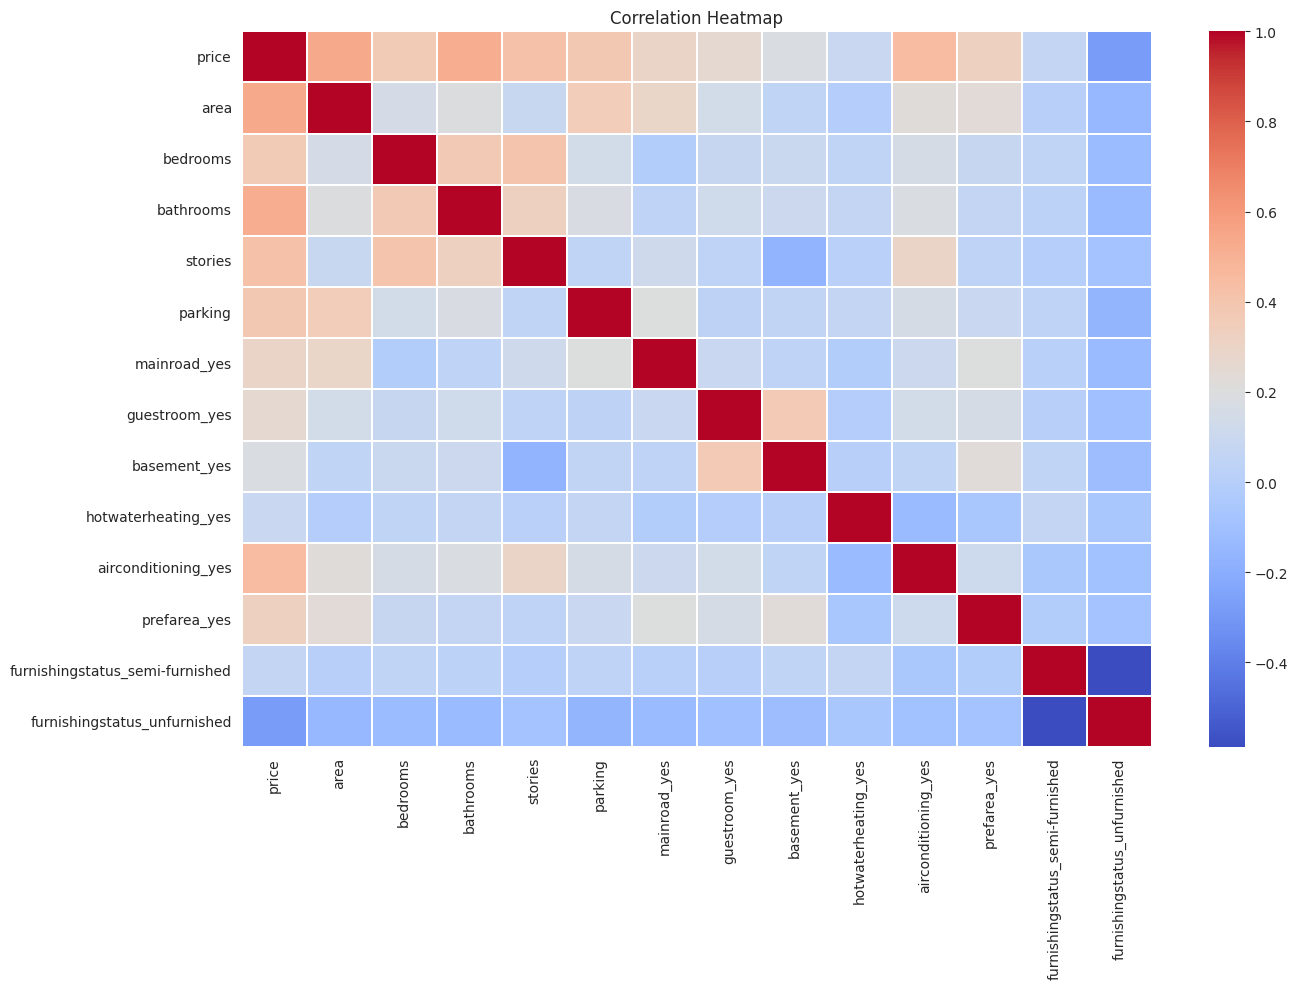

In [ ]:
# Correlation between numerical features


plt.figure(figsize=(14,10))

correlation_matrix = housing_data.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/XylofyAI/charts/correlation_heatmap.png")

plt.show()

**Correlation with Price**
---

In [46]:
correlation_with_price = (
    housing_data
    .corr(numeric_only=True)["price"]
    .sort_values(ascending=False)
)

correlation_with_price

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning_yes,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea_yes,0.329777
mainroad_yes,0.296898
guestroom_yes,0.255517


### Observation

Among the numerical variables, **area** and **bathrooms** exhibit the strongest positive correlation with house prices, indicating that larger properties with more bathrooms generally command higher market values.

**6. Data Preprocessing**
---

# Encoding Categorical Features

Machine learning algorithms require numerical input, whereas this dataset contains several categorical features represented as text values such as **yes/no** and furnishing status.

To make these features suitable for model training, one-hot encoding is applied.

Using `drop_first=True` avoids redundant columns and helps prevent multicollinearity in regression models.

**One-Hot Encoding**
---

In [17]:
# Converting categorical columns into numerical form

categorical_features = housing_data.select_dtypes(include="object").columns

print("Categorical Features")
print("-" * 40)

print(categorical_features.tolist())

# Applying One-Hot Encoding
housing_data = pd.get_dummies(
    housing_data,
    columns=categorical_features,
    drop_first=True
)

print("\nDataset after encoding")
print("-" * 40)

housing_data.head()

Categorical Features
----------------------------------------
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Dataset after encoding
----------------------------------------


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


**Verifying Dataset After Encoding**
---

In [18]:

print("Updated Dataset Information")
print("-" * 40)

housing_data.info()

print("\nPreview of the transformed dataset")

housing_data.head()

Updated Dataset Information
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


**Cleaning summary:** no missing values to fill, no duplicates found. The six yes/no fields were mapped to 1/0, and `furnishingstatus` was one-hot encoded (`drop_first=True` avoids the dummy-variable trap). All columns are meaningful property attributes, so all are retained.

# Preparing the Dataset for Model Training

Before training a machine learning model, the dataset must be separated into:

- **Input Features (Independent Variables):** These are the property characteristics used to predict house prices.
- **Target Variable (Dependent Variable):** This represents the actual selling price of the house.

Separating the features from the target variable allows the learning algorithms to understand the relationship between property attributes and their corresponding prices.

**Feature Selection**
---

In [19]:

# Separating input features and target variable


input_features = housing_data.drop(columns="price")

target_prices = housing_data["price"]

print("Input Feature Matrix Shape :", input_features.shape)
print("Target Variable Shape      :", target_prices.shape)

Input Feature Matrix Shape : (545, 13)
Target Variable Shape      : (545,)


**Train Test Split**
---

In [20]:
# Splitting the dataset into training and testing sets

training_features, testing_features, training_prices, testing_prices = train_test_split(
    input_features,
    target_prices,
    test_size=0.20,
    random_state=42
)

print("Training Feature Shape :", training_features.shape)
print("Testing Feature Shape  :", testing_features.shape)

print("\nTraining Labels :", training_prices.shape)
print("Testing Labels  :", testing_prices.shape)

Training Feature Shape : (436, 13)
Testing Feature Shape  : (109, 13)

Training Labels : (436,)
Testing Labels  : (109,)


**7. Model Building & Evaluation**
---

# Linear Regression Model

Linear Regression estimates a linear relationship between the input features and the target variable.

Although it is relatively simple, Linear Regression serves as an excellent baseline model for comparing the performance of more advanced algorithms.

**Training Linear Regression Model**
---

In [21]:
linear_regression_model = LinearRegression()

linear_regression_model.fit(
    training_features,
    training_prices
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Predictions**
---

In [22]:

# Predicting the house prices using the trained Linear Regression model

predicted_prices_lr = linear_regression_model.predict(testing_features)

prediction_results_lr = pd.DataFrame({
    "Actual Price": testing_prices.values,
    "Predicted Price": predicted_prices_lr.astype(int)
})

prediction_results_lr.head(10)

,Actual Price,Predicted Price
0,4060000,5164653
1,6650000,7224722
2,3710000,3109863
3,6440000,4612075
4,2800000,3294646
5,4900000,3532275
6,5250000,5611774
7,4543000,6368145
8,2450000,2722856
9,3353000,2629405


**Evaluating Linear Regression**
---

In [23]:
linear_mae = mean_absolute_error(
    testing_prices,
    predicted_prices_lr
)

linear_rmse = np.sqrt(
    mean_squared_error(
        testing_prices,
        predicted_prices_lr
    )
)

linear_r2 = r2_score(
    testing_prices,
    predicted_prices_lr
)

linear_accuracy = linear_r2 * 100

print("-------------------------------")
print("Linear Regression Performance")
print("--------------------------------" )

print(f"Mean Absolute Error (MAE)      : {linear_mae:,.2f}")

print(f"Root Mean Squared Error (RMSE) : {linear_rmse:,.2f}")

print(f"R² Score                       : {linear_r2:.4f}")

print(f"Model Accuracy                 : {linear_accuracy:.2f}%")

-------------------------------
Linear Regression Performance
--------------------------------
Mean Absolute Error (MAE)      : 970,043.40
Root Mean Squared Error (RMSE) : 1,324,506.96
R² Score                       : 0.6529
Model Accuracy                 : 65.29%


# Random Forest Regression

Linear Regression assumes a linear relationship between the input features and the target variable. However, real-world housing data often contains complex and non-linear relationships.

To capture these patterns, a **Random Forest Regressor** is trained. Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees, resulting in better prediction accuracy and reduced overfitting.

The performance of this model will be compared with Linear Regression using the same evaluation metrics.

**Training Random Forest**
---

In [24]:
# Training the Random Forest Regressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    training_features,
    training_prices
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Predictions**
---

In [25]:
# Predicting the house prices using Random Forest

predicted_prices_rf = random_forest_model.predict(
    testing_features
)

prediction_results_rf = pd.DataFrame({
    "Actual Price": testing_prices.values,
    "Predicted Price": predicted_prices_rf.astype(int)
})

prediction_results_rf.head(10)

,Actual Price,Predicted Price
0,4060000,5377680
1,6650000,7287070
2,3710000,3747528
3,6440000,4502120
4,2800000,3748885
5,4900000,3432660
6,5250000,5070240
7,4543000,5050080
8,2450000,2572220
9,3353000,2822893


**Evaluating Random Forest**
---

In [27]:
# Evaluating the Random Forest performance

forest_mae = mean_absolute_error(
    testing_prices,
    predicted_prices_rf
)

forest_rmse = np.sqrt(
    mean_squared_error(
        testing_prices,
        predicted_prices_rf
    )
)

forest_r2 = r2_score(
    testing_prices,
    predicted_prices_rf
)

forest_accuracy = forest_r2 * 100

print("----------------------------" )
print("Random Forest Performance")
print("----------------------------" )

print(f"Mean Absolute Error (MAE)      : {forest_mae:,.2f}")

print(f"Root Mean Squared Error (RMSE) : {forest_rmse:,.2f}")

print(f"R² Score                       : {forest_r2:.4f}")

print(f"Model Accuracy                 : {forest_accuracy:.2f}%")

----------------------------
Random Forest Performance
----------------------------
Mean Absolute Error (MAE)      : 1,021,546.04
Root Mean Squared Error (RMSE) : 1,400,565.97
R² Score                       : 0.6119
Model Accuracy                 : 61.19%


**8. Comparing the Performance of Both Models**
---

To understand which algorithm performs better on the housing dataset, the evaluation metrics of both models are summarized in a comparison table.

The model with the lower MAE and RMSE values, along with a higher R² Score, is considered to provide better prediction performance.

In [28]:
# Comparing both regression models


performance_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        forest_rmse
    ],
    "R² Score": [
        linear_r2,
        forest_r2
    ],
    "Accuracy (%)": [
        linear_accuracy,
        forest_accuracy
    ]
})

performance_summary

,Model,MAE,RMSE,R² Score,Accuracy (%)
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924,65.292426
1,Random Forest,1.021546e+06,1.400566e+06,0.611919,61.191853


**Model comparison:** On this test split, **Linear Regression performs slightly better** (R² ≈ 0.65, MAE ≈ ₹0.97M) than Random Forest (R² ≈ 0.61, MAE ≈ ₹1.01M). With only ~545 rows and mostly linear feature–price relationships, the simpler model generalises better; Random Forest tends to overfit the small training set.

# Visualizing the Data

Data visualization helps in understanding the distribution of house prices, relationships between different variables, and the quality of model predictions.

The following visualizations are included:

- Distribution of house prices
- Correlation heatmap
- Actual vs Predicted house prices
- Feature importance obtained from the Random Forest model

**Histogram - Distribution of house prices**
---

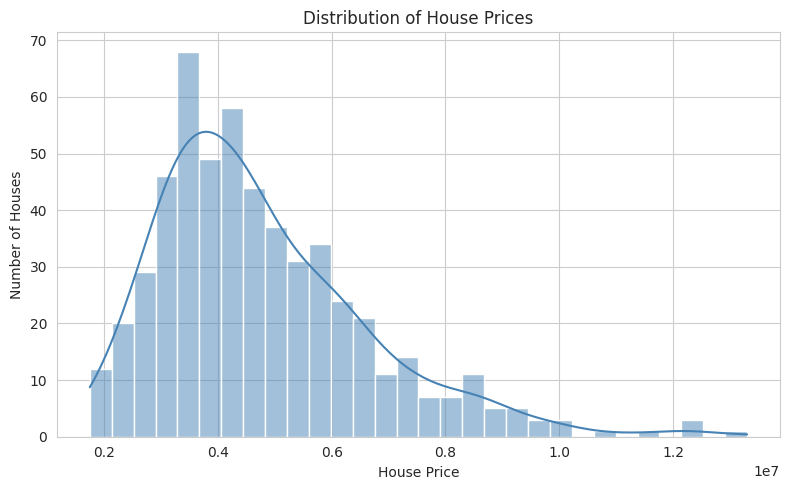

In [30]:
# Distribution of house prices


plt.figure(figsize=(8,5))

sns.histplot(
    housing_data["price"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of House Prices")

plt.xlabel("House Price")

plt.ylabel("Number of Houses")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/XylofyAI/charts/price_distribution.png")

plt.show()

The price distribution is **right-skewed**: most homes sit between ₹3M and ₹6M, with a long tail of a few expensive properties pulling the average upward.

`area` (0.54) and `bathrooms` (0.52) show the strongest positive correlation with price, followed by `airconditioning` (0.45) and `stories` (0.42). Being `unfurnished` correlates negatively (−0.28).

**Actual vs Predicted Prices Plot**
---

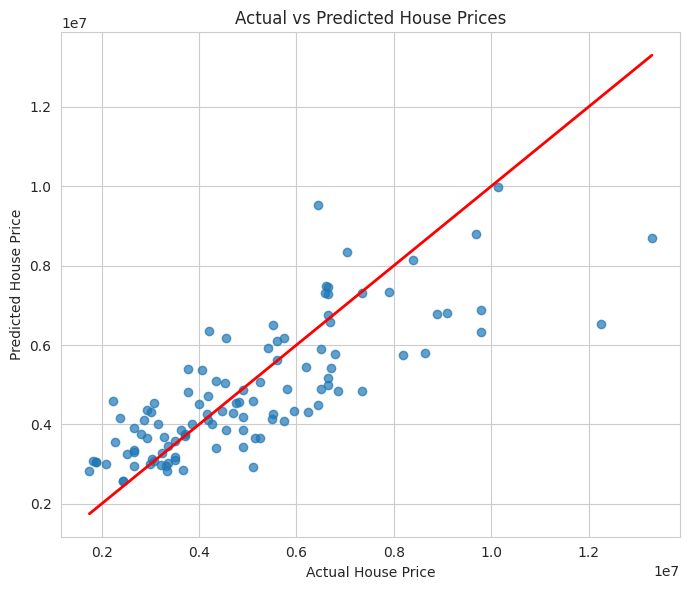

In [34]:
# Comparing actual and predicted prices


plt.figure(figsize=(7,6))

plt.scatter(
    testing_prices,
    predicted_prices_rf,
    alpha=0.7
)

plt.plot(
    [testing_prices.min(), testing_prices.max()],
    [testing_prices.min(), testing_prices.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/XylofyAI/charts/actual_vs_predicted.png")

plt.show()

Predictions track the diagonal reasonably well in the mid-price range but **under-predict the most expensive homes** — a common effect when high-end properties are rare in the data.

**Feature Importance**
---

In [35]:
# Identifying the most important features responsible


feature_importance = pd.DataFrame({
    "Feature": training_features.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


**Feature Importance Plot**
---

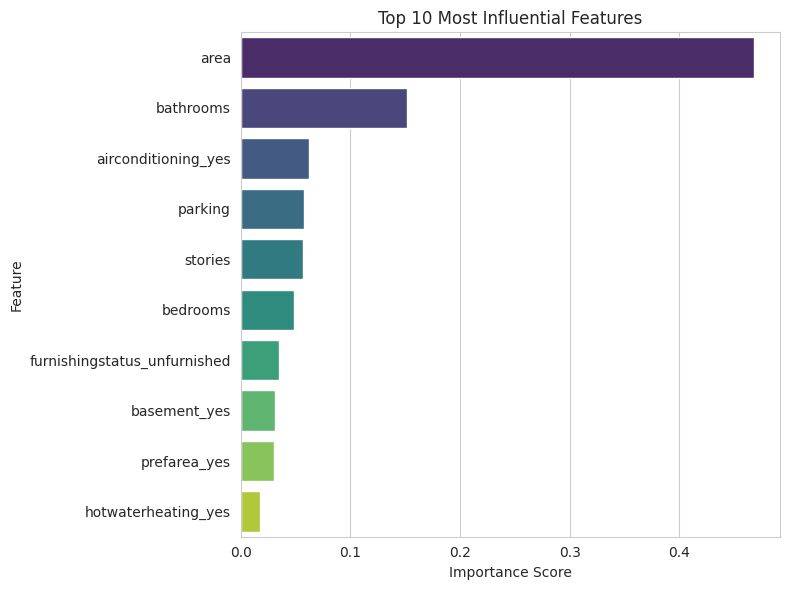

In [37]:
# Plotting the top important features

plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Most Influential Features")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/XylofyAI/charts/feature_importance.png")

plt.show()

##**9. Observations**
Based on exploring the data and evaluating the models, here are the main things I noticed about the housing dataset:

1. House Size is the Biggest Factor: The total area of the property is the strongest indicator of price. Bigger houses naturally cost a lot more.

2. Bathrooms Over Bedrooms: Surprisingly, having more bathrooms increases the house price more than adding extra bedrooms. Also, having dedicated parking makes a big difference in value.
3. Air Conditioning and Location: Houses with AC and those located in popular or preferred neighborhoods are noticeably more expensive than standard homes.
4. Furnished vs Unfurnished: Fully furnished houses do sell for more money, but it's not as big of a deal as foundational things like the house size or location.
5. Simple Models Worked Better: I expected the more complex Random Forest model to win, but Linear Regression actually did better! This tells us that the relationship between house features and prices is mostly straightforward and linear. Random Forest probably overfitted because our dataset is pretty small (only 545 rows).
6. Hard to Predict Luxury Homes: The "Actual vs Predicted" scatter plot shows that the model is good at guessing the price of normal homes, but it usually guesses too low for really expensive ones. This makes sense because luxury homes probably have special features or designs that aren't recorded in our basic dataset.
##Final Insights
From this project, I learned exactly what makes a house expensive. The data clearly shows that buyers are mostly paying for more physical space and basic comforts like extra bathrooms and AC.

If I were advising a real estate agency based on this data, my main suggestion would be to highlight the floor area, bathroom count, and air conditioning when marketing a home, since these justify a higher asking price. Also, while machine learning is great for estimating standard house prices quickly, human experts are still needed to price luxury or unique homes properly, since algorithms struggle with unrecorded premium features.

##Conclusion
This project was a great way to experience a complete machine learning workflow from start to finish. I started by cleaning and visualizing the dataset to understand the housing market trends, and then I prepared the data using one-hot encoding so the algorithms could read it.

By comparing Linear Regression and Random Forest, I learned an important lesson: more complex machine learning models aren't always better. Because the dataset was relatively small and had mostly straight-forward relationships, the simpler Linear Regression model actually gave us more accurate predictions and a better R² score.

Overall, this project showed me how helpful machine learning can be in the real world. By using predictive models, buyers, sellers, and agents can get a fast, data-backed estimate of a property's value instead of just guessing.